In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df=pd.read_csv("../data/raw/cs-training.csv")
TARGET="SeriousDlqin2yrs"
df_clean=df.copy()

In [4]:
df_clean=df_clean.drop(columns=["Unnamed: 0"])

In [5]:
delinquency_cols=[
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

df_clean["DelinquencyAnomaly"]=(df_clean[delinquency_cols].isin([96,98]).any(axis=1).astype(int))

In [6]:
df_clean[delinquency_cols] = (
    df_clean[delinquency_cols]
    .replace([96, 98], np.nan)
)

In [7]:
df_clean.loc[
    df_clean["age"] == 0,
    "age"
] = np.nan

In [8]:
df_clean["IncomeMissing"] = (
    df_clean["MonthlyIncome"]
    .isna()
    .astype(int)
)

In [9]:
X=df_clean.drop(columns=[TARGET])
Y=df_clean[TARGET]

In [10]:
print(X.shape)
print(Y.shape)

(150000, 12)
(150000,)


In [11]:
X_train, X_val, Y_train, Y_val=train_test_split(X,Y,test_size=0.20,stratify=Y,random_state=42)

In [12]:
print("Overall:")
print(Y.value_counts(normalize=True) * 100)

print("\nTraining:")
print(Y_train.value_counts(normalize=True) * 100)

print("\nValidation:")
print(Y_val.value_counts(normalize=True) * 100)

Overall:
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

Training:
SeriousDlqin2yrs
0    93.315833
1     6.684167
Name: proportion, dtype: float64

Validation:
SeriousDlqin2yrs
0    93.316667
1     6.683333
Name: proportion, dtype: float64


In [13]:
logistic_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]
)

In [14]:
logistic_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberOfDependents', 'DelinquencyAnomaly','IncomeMissing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_v

In [15]:
Y_pred = logistic_pipeline.predict(X_val)

Y_proba = logistic_pipeline.predict_proba(X_val)[:, 1]

In [16]:
roc_auc = roc_auc_score(Y_val, Y_proba)
pr_auc = average_precision_score(Y_val, Y_proba)

precision = precision_score(Y_val, Y_pred)
recall = recall_score(Y_val, Y_pred)
f1 = f1_score(Y_val, Y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred))

ROC-AUC: 0.8205222699635979
PR-AUC: 0.35987298225212094
Precision: 0.5928030303030303
Recall: 0.15610972568578554
F1: 0.24713778128701144

Confusion Matrix:
[[27780   215]
 [ 1692   313]]


In [17]:
balanced_logistic_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced"
            )
        )
    ]
)

In [18]:
balanced_logistic_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberOfDependents', 'DelinquencyAnomaly','IncomeMissing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_v

In [19]:
Y_pred_balanced = balanced_logistic_pipeline.predict(X_val)

Y_proba_balanced = (
    balanced_logistic_pipeline
    .predict_proba(X_val)[:, 1]
)

In [20]:
roc_auc_balanced = roc_auc_score(
    Y_val,
    Y_proba_balanced
)

pr_auc_balanced = average_precision_score(
    Y_val,
    Y_proba_balanced
)

precision_balanced = precision_score(
    Y_val,
    Y_pred_balanced
)

recall_balanced = recall_score(
    Y_val,
    Y_pred_balanced
)

f1_balanced = f1_score(
    Y_val,
    Y_pred_balanced
)

In [21]:
print("ROC-AUC:", roc_auc_balanced)
print("PR-AUC:", pr_auc_balanced)
print("Precision:", precision_balanced)
print("Recall:", recall_balanced)
print("F1:", f1_balanced)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred_balanced))

ROC-AUC: 0.8255127229256738
PR-AUC: 0.36288402214113
Precision: 0.2707797772065124
Recall: 0.6304239401496259
F1: 0.37884010190319195

Confusion Matrix:
[[24591  3404]
 [  741  1264]]


In [22]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Model": "Logistic Regression (Balanced)",
        "ROC-AUC": roc_auc_balanced,
        "PR-AUC": pr_auc_balanced,
        "Precision": precision_balanced,
        "Recall": recall_balanced,
        "F1": f1_balanced
    }
])

comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.820522,0.359873,0.592803,0.156110,0.247138
1,Logistic Regression (Balanced),0.825513,0.362884,0.270780,0.630424,0.378840


In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
random_forest_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [25]:
random_forest_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberOfDependents', 'DelinquencyAnomaly','IncomeMissing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` 

In [26]:
Y_pred_rf = random_forest_pipeline.predict(X_val)

Y_proba_rf = (
    random_forest_pipeline
    .predict_proba(X_val)[:, 1]
)

In [27]:
roc_auc_rf = roc_auc_score(
    Y_val,
    Y_proba_rf
)

pr_auc_rf = average_precision_score(
    Y_val,
    Y_proba_rf
)

precision_rf = precision_score(
    Y_val,
    Y_pred_rf
)

recall_rf = recall_score(
    Y_val,
    Y_pred_rf
)

f1_rf = f1_score(
    Y_val,
    Y_pred_rf
)

In [28]:
print("ROC-AUC:", roc_auc_rf)
print("PR-AUC:", pr_auc_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1:", f1_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred_rf))

ROC-AUC: 0.8486532463269402
PR-AUC: 0.3712352165475321
Precision: 0.5761904761904761
Recall: 0.18104738154613467
F1: 0.27552182163187855

Confusion Matrix:
[[27728   267]
 [ 1642   363]]


In [29]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Model": "Logistic Regression (Balanced)",
        "ROC-AUC": roc_auc_balanced,
        "PR-AUC": pr_auc_balanced,
        "Precision": precision_balanced,
        "Recall": recall_balanced,
        "F1": f1_balanced
    },
    {
        "Model": "Random Forest",
        "ROC-AUC": roc_auc_rf,
        "PR-AUC": pr_auc_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1": f1_rf
    }
])

comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.820522,0.359873,0.592803,0.156110,0.247138
1,Logistic Regression (Balanced),0.825513,0.362884,0.270780,0.630424,0.378840
2,Random Forest,0.848653,0.371235,0.576190,0.181047,0.275522


In [30]:
balanced_random_forest_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [31]:
balanced_random_forest_pipeline.fit(
    X_train,
    Y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberOfDependents', 'DelinquencyAnomaly','IncomeMissing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` 

In [32]:
Y_pred_rf_balanced = (
    balanced_random_forest_pipeline.predict(X_val)
)

Y_proba_rf_balanced = (
    balanced_random_forest_pipeline
    .predict_proba(X_val)[:, 1]
)

In [33]:
roc_auc_rf_balanced = roc_auc_score(
    Y_val,
    Y_proba_rf_balanced
)

pr_auc_rf_balanced = average_precision_score(
    Y_val,
    Y_proba_rf_balanced
)

precision_rf_balanced = precision_score(
    Y_val,
    Y_pred_rf_balanced
)

recall_rf_balanced = recall_score(
    Y_val,
    Y_pred_rf_balanced
)

f1_rf_balanced = f1_score(
    Y_val,
    Y_pred_rf_balanced
)

print("ROC-AUC:", roc_auc_rf_balanced)
print("PR-AUC:", pr_auc_rf_balanced)
print("Precision:", precision_rf_balanced)
print("Recall:", recall_rf_balanced)
print("F1:", f1_rf_balanced)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred_rf_balanced))

ROC-AUC: 0.8467827306176423
PR-AUC: 0.34675941741874305
Precision: 0.42656524283206554
Recall: 0.3635910224438903
F1: 0.3925686591276252

Confusion Matrix:
[[27015   980]
 [ 1276   729]]


In [34]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Model": "Logistic Regression (Balanced)",
        "ROC-AUC": roc_auc_balanced,
        "PR-AUC": pr_auc_balanced,
        "Precision": precision_balanced,
        "Recall": recall_balanced,
        "F1": f1_balanced
    },
    {
        "Model": "Random Forest",
        "ROC-AUC": roc_auc_rf,
        "PR-AUC": pr_auc_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1": f1_rf
    },
    {
        "Model": "Random Forest (Balanced)",
        "ROC-AUC": roc_auc_rf_balanced,
        "PR-AUC": pr_auc_rf_balanced,
        "Precision": precision_rf_balanced,
        "Recall": recall_rf_balanced,
        "F1": f1_rf_balanced
    }
])

comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.820522,0.359873,0.592803,0.156110,0.247138
1,Logistic Regression (Balanced),0.825513,0.362884,0.270780,0.630424,0.378840
2,Random Forest,0.848653,0.371235,0.576190,0.181047,0.275522
3,Random Forest (Balanced),0.846783,0.346759,0.426565,0.363591,0.392569


In [35]:
from xgboost import XGBClassifier

In [36]:
xgb_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="auc",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [37]:
xgb_pipeline.fit(X_train, Y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberOfDependents', 'DelinquencyAnomaly','IncomeMissing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` 

In [38]:
Y_pred_xgb = xgb_pipeline.predict(X_val)

Y_proba_xgb = (
    xgb_pipeline
    .predict_proba(X_val)[:, 1]
)

In [39]:
roc_auc_xgb = roc_auc_score(
    Y_val,
    Y_proba_xgb
)

pr_auc_xgb = average_precision_score(
    Y_val,
    Y_proba_xgb
)

precision_xgb = precision_score(
    Y_val,
    Y_pred_xgb
)

recall_xgb = recall_score(
    Y_val,
    Y_pred_xgb
)

f1_xgb = f1_score(
    Y_val,
    Y_pred_xgb
)

print("ROC-AUC:", roc_auc_xgb)
print("PR-AUC:", pr_auc_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1:", f1_xgb)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred_xgb))

ROC-AUC: 0.8693462272163848
PR-AUC: 0.40999472401783377
Precision: 0.6051051051051051
Recall: 0.20099750623441395
F1: 0.3017596405840509

Confusion Matrix:
[[27732   263]
 [ 1602   403]]


In [40]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Model": "Logistic Regression (Balanced)",
        "ROC-AUC": roc_auc_balanced,
        "PR-AUC": pr_auc_balanced,
        "Precision": precision_balanced,
        "Recall": recall_balanced,
        "F1": f1_balanced
    },
    {
        "Model": "Random Forest",
        "ROC-AUC": roc_auc_rf,
        "PR-AUC": pr_auc_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1": f1_rf
    },
    {
        "Model": "Random Forest (Balanced)",
        "ROC-AUC": roc_auc_rf_balanced,
        "PR-AUC": pr_auc_rf_balanced,
        "Precision": precision_rf_balanced,
        "Recall": recall_rf_balanced,
        "F1": f1_rf_balanced
    },
    {
        "Model": "XG Boost",
        "ROC-AUC": roc_auc_xgb,
        "PR-AUC": pr_auc_xgb,
        "Precision": precision_xgb,
        "Recall": recall_xgb,
        "F1": f1_xgb
    }
])

comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.820522,0.359873,0.592803,0.156110,0.247138
1,Logistic Regression (Balanced),0.825513,0.362884,0.270780,0.630424,0.378840
2,Random Forest,0.848653,0.371235,0.576190,0.181047,0.275522
3,Random Forest (Balanced),0.846783,0.346759,0.426565,0.363591,0.392569
4,XG Boost,0.869346,0.409995,0.605105,0.200998,0.301760


In [41]:
from sklearn.model_selection import RandomizedSearchCV

In [42]:
param_dist = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

In [43]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [44]:
xgb_search.fit(X_train, Y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.02, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be

In [45]:
print("Best ROC-AUC:", xgb_search.best_score_)
print("\nBest Parameters:")
print(xgb_search.best_params_)

Best ROC-AUC: 0.8643440935133846

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 7, 'model__max_depth': 4, 'model__learning_rate': 0.02, 'model__gamma': 0.3, 'model__colsample_bytree': 0.8}


In [46]:
best_xgb = xgb_search.best_estimator_

Y_pred_xgb_tuned = best_xgb.predict(X_val)

Y_proba_xgb_tuned = (
    best_xgb.predict_proba(X_val)[:, 1]
)

In [47]:
roc_auc_xgb_tuned = roc_auc_score(
    Y_val,
    Y_proba_xgb_tuned
)

pr_auc_xgb_tuned = average_precision_score(
    Y_val,
    Y_proba_xgb_tuned
)

precision_xgb_tuned = precision_score(
    Y_val,
    Y_pred_xgb_tuned
)

recall_xgb_tuned = recall_score(
    Y_val,
    Y_pred_xgb_tuned
)

f1_xgb_tuned = f1_score(
    Y_val,
    Y_pred_xgb_tuned
)

print("ROC-AUC:", roc_auc_xgb_tuned)
print("PR-AUC:", pr_auc_xgb_tuned)
print("Precision:", precision_xgb_tuned)
print("Recall:", recall_xgb_tuned)
print("F1:", f1_xgb_tuned)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred_xgb_tuned))

ROC-AUC: 0.8692187641273669
PR-AUC: 0.4098402512817095
Precision: 0.6064516129032258
Recall: 0.18753117206982545
F1: 0.2864761904761905

Confusion Matrix:
[[27751   244]
 [ 1629   376]]


In [48]:
from sklearn.metrics import accuracy_score

In [49]:
accuracy_xgb = accuracy_score(
    Y_val,
    Y_pred_xgb
)

print("Accuracy:", accuracy_xgb)

Accuracy: 0.9378333333333333


In [50]:
print(f"Accuracy: {accuracy_xgb * 100:.2f}%")

Accuracy: 93.78%


In [51]:
Y_pred_xgb_tuned

array([0, 0, 0, ..., 0, 0, 0], shape=(30000,))

In [52]:
accuracy_xgb_tuned = accuracy_score(
    Y_val,
    Y_pred_xgb_tuned
)

print(f"Tuned XGBoost Accuracy: {accuracy_xgb_tuned * 100:.2f}%")

Tuned XGBoost Accuracy: 93.76%


In [53]:
thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        Y_proba_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            Y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            Y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            Y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            Y_val,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1,Accuracy
0,0.10,0.278173,0.683292,0.395382,0.860333
1,0.15,0.354897,0.585536,0.441935,0.901167
2,0.20,0.400234,0.511222,0.448971,0.916133
3,0.25,0.438766,0.453865,0.446188,0.924700
4,0.30,0.469303,0.396509,0.429846,0.929700
5,0.35,0.505147,0.342643,0.408321,0.933633
6,0.40,0.546468,0.293267,0.381694,0.936500
7,0.45,0.585106,0.246883,0.347247,0.937967
8,0.50,0.605105,0.200998,0.301760,0.937833


In [54]:
best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_f1_row

Threshold    0.200000
Precision    0.400234
Recall       0.511222
F1           0.448971
Accuracy     0.916133
Name: 2, dtype: float64

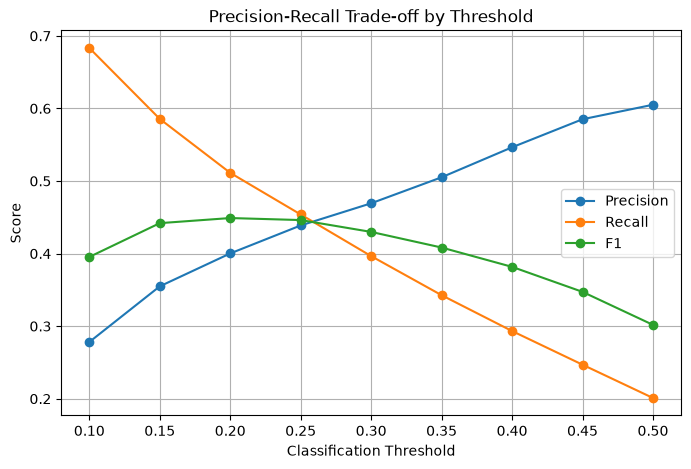

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
import shap

print(shap.__version__)

0.52.0


In [57]:
# Extract the trained XGBoost model from the pipeline

xgb_model = xgb_pipeline.named_steps["model"]

print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [58]:
xgb_pipeline.named_steps["model"]

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [59]:
# Apply the same preprocessing used during model training

X_val_transformed = xgb_pipeline.named_steps["imputer"].transform(X_val)

print(X_val_transformed.shape)

(30000, 12)


In [60]:
# Create SHAP explainer for the XGBoost model

explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created successfully")

SHAP explainer created successfully


In [61]:
# Use a sample of validation data for SHAP analysis

X_shap = X_val_transformed[:2000]

shap_values = explainer.shap_values(X_shap)

print(shap_values.shape)

(2000, 12)


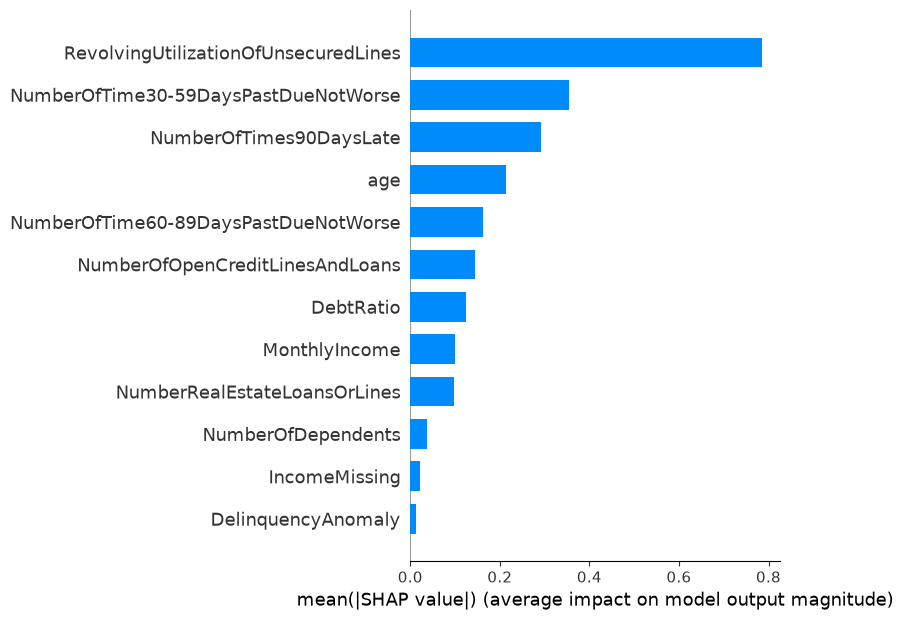

In [62]:
# Global feature importance using SHAP

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns,
    plot_type="bar"
)

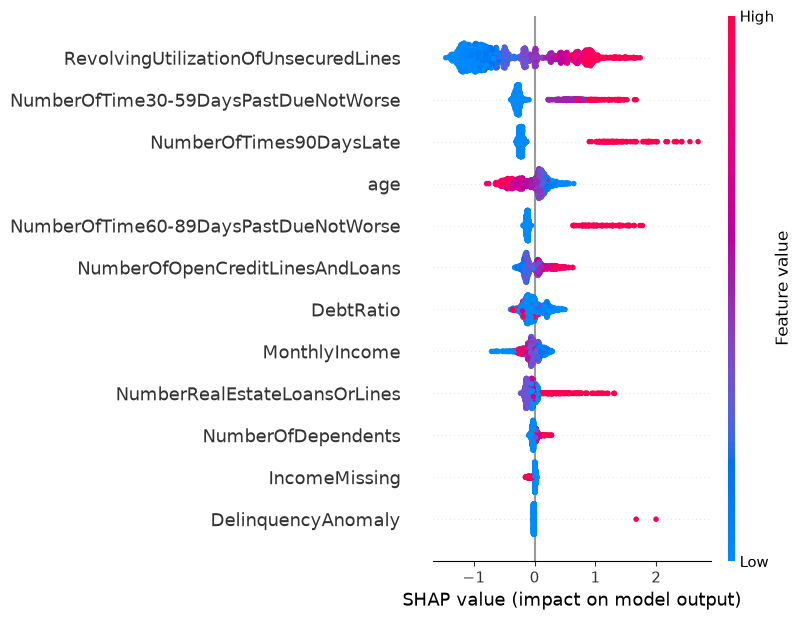

In [63]:
# SHAP summary plot showing feature impact and direction

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns
)

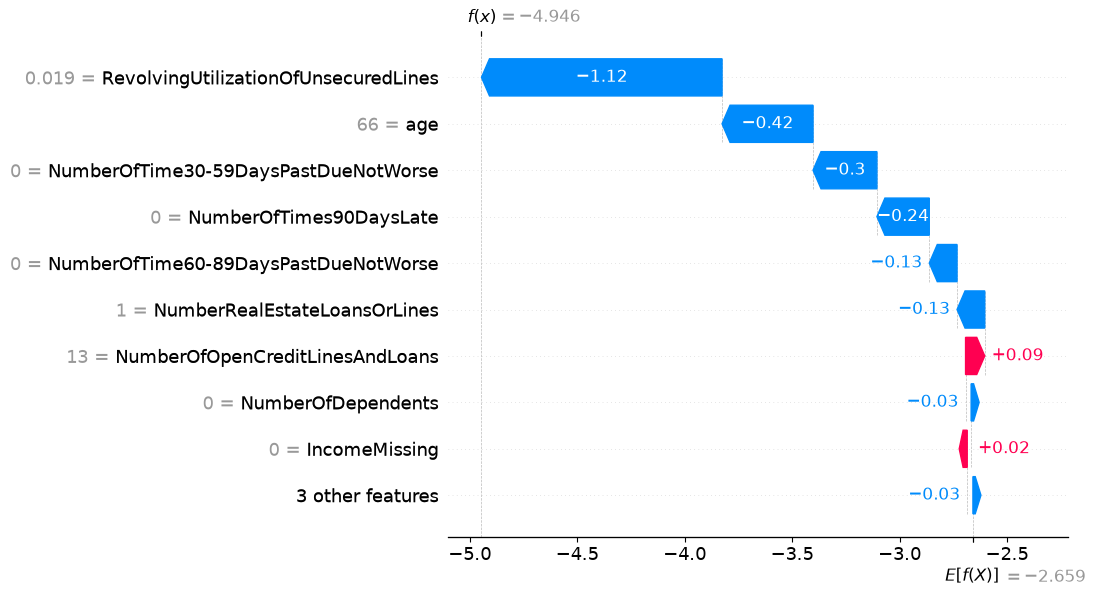

In [64]:
# Explain one individual borrower

sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_shap[sample_index],
        feature_names=X.columns
    )
)

In [65]:
import mlflow

print(mlflow.__version__)

3.16.1


In [66]:
import mlflow
import mlflow.xgboost

# Create/select our MLflow experiment
mlflow.set_experiment("Loan Default Prediction")

<Experiment: artifact_location='file:c:/Users/Acer/Desktop/Loan-Default-Predictor/notebooks/mlruns/1', creation_time=1790764732005, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790764732005, lifecycle_stage='active', name='Loan Default Prediction', tags={}, trace_location=None, workspace='default'>

In [67]:
with mlflow.start_run(run_name="XGBoost Baseline"):

    # Log model parameters
    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    })

    # Log validation metrics
    mlflow.log_metrics({
        "roc_auc": 0.869346,
        "pr_auc": 0.409995,
        "precision": 0.605105,
        "recall": 0.2000,
        "f1": 0.301760
    })

    print("XGBoost baseline run logged successfully.")

XGBoost baseline run logged successfully.


In [68]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


In [69]:
import mlflow
import mlflow.xgboost

mlflow.set_experiment("Loan Default Prediction")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790786016619, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790786016619, lifecycle_stage='active', name='Loan Default Prediction', tags={}, trace_location=None, workspace='default'>

In [70]:
with mlflow.start_run(run_name="XGBoost Baseline"):

    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    })

    mlflow.log_metrics({
        "roc_auc": 0.869346,
        "pr_auc": 0.409995,
        "precision": 0.605105,
        "recall": 0.2000,
        "f1": 0.301760
    })

    print("XGBoost baseline run logged successfully.")

XGBoost baseline run logged successfully.
🏃 View run XGBoost Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/2fc1157ecc8e4b04aebb0bd511547e0c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [71]:
import mlflow

mlflow.set_experiment("Loan Default Prediction")

print("Experiment configured successfully.")

Experiment configured successfully.


In [72]:
with mlflow.start_run(run_name="XGBoost Baseline"):

    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    })

    mlflow.log_metrics({
        "roc_auc": 0.869346,
        "pr_auc": 0.409995,
        "precision": 0.605105,
        "recall": 0.2000,
        "f1": 0.301760
    })

    print("XGBoost baseline run logged successfully.")

XGBoost baseline run logged successfully.
🏃 View run XGBoost Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/c67502e47aff45f3b5aa19826305ca66
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [73]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


In [74]:
mlflow.set_experiment("Loan Default Prediction")

print("Experiment:", mlflow.get_experiment_by_name("Loan Default Prediction"))

Experiment: <Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790786016619, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790786016619, lifecycle_stage='active', name='Loan Default Prediction', tags={}, trace_location=None, workspace='default'>


In [75]:
with mlflow.start_run(run_name="XGBoost Baseline"):

    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    })

    mlflow.log_metrics({
        "roc_auc": 0.869346,
        "pr_auc": 0.409995,
        "precision": 0.605105,
        "recall": 0.2000,
        "f1": 0.301760
    })

    print("XGBoost baseline run logged successfully.")

XGBoost baseline run logged successfully.
🏃 View run XGBoost Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/8c393105c6294e518084e69d079ec361
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [76]:
with mlflow.start_run(run_name="XGBoost Baseline"):

    # Log model parameters
    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    })

    # Log validation metrics
    mlflow.log_metrics({
        "roc_auc": 0.869346,
        "pr_auc": 0.409995,
        "precision": 0.605105,
        "recall": 0.2000,
        "f1": 0.301760
    })

    # Log the trained XGBoost model
    mlflow.xgboost.log_model(
        xgb_model,
        name="xgboost_model"
    )

    print("XGBoost model logged successfully.")

XGBoost model logged successfully.
🏃 View run XGBoost Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/3964d3166c5648f8a5ce05099262823e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [77]:
with mlflow.start_run(run_name="XGBoost Full Pipeline"):

    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    })

    mlflow.log_metrics({
        "roc_auc": 0.869346,
        "pr_auc": 0.409995,
        "precision": 0.605105,
        "recall": 0.2000,
        "f1": 0.301760
    })

    mlflow.sklearn.log_model(
        xgb_pipeline,
        name="xgb_full_pipeline",
        serialization_format="cloudpickle"
    )

    print("Full XGBoost pipeline logged successfully.")

2026/10/01 09:49:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Full XGBoost pipeline logged successfully.
🏃 View run XGBoost Full Pipeline at: http://127.0.0.1:5000/#/experiments/1/runs/01d58966c3624eda9657a8e144825568
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [78]:
# Now Working with test data

In [80]:
# ==========================================
# FINAL TEST EVALUATION
# ==========================================

test_df = pd.read_csv("../data/raw/cs-test.csv")

print("Test shape:", test_df.shape)
print("Target present:", "SeriousDlqin2yrs" in test_df.columns)
print(test_df.head())

Test shape: (101503, 12)
Target present: True
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1               NaN                              0.885519   43   
1           2               NaN                              0.463295   57   
2           3               NaN                              0.043275   59   
3           4               NaN                              0.280308   38   
4           5               NaN                              1.000000   27   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     0   0.177513         5700.0   
1                                     0   0.527237         9141.0   
2                                     0   0.687648         5083.0   
3                                     1   0.925961         3200.0   
4                                     0   0.019917         3865.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0      

In [81]:
test_clean = test_df.copy()

# Remove ID column
if "Unnamed: 0" in test_clean.columns:
    test_clean = test_clean.drop(columns=["Unnamed: 0"])

# Missing income indicator
test_clean["IncomeMissing"] = (
    test_clean["MonthlyIncome"].isna().astype(int)
)

# Delinquency anomaly indicator
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

test_clean["DelinquencyAnomaly"] = (
    test_clean[delinq_cols]
    .isin([96, 98])
    .any(axis=1)
    .astype(int)
)

# Replace anomalous values with NaN
test_clean[delinq_cols] = test_clean[delinq_cols].replace([96, 98], pd.NA)

# Invalid age
test_clean.loc[test_clean["age"] == 0, "age"] = pd.NA

print("Test shape after cleaning:", test_clean.shape)
print("\nMissing values:")
print(test_clean.isna().sum())

Test shape after cleaning: (101503, 13)

Missing values:
SeriousDlqin2yrs                        101503
RevolvingUtilizationOfUnsecuredLines         0
age                                          0
NumberOfTime30-59DaysPastDueNotWorse       214
DebtRatio                                    0
MonthlyIncome                            20103
NumberOfOpenCreditLinesAndLoans              0
NumberOfTimes90DaysLate                    214
NumberRealEstateLoansOrLines                 0
NumberOfTime60-89DaysPastDueNotWorse       214
NumberOfDependents                        2626
IncomeMissing                                0
DelinquencyAnomaly                           0
dtype: int64


In [85]:
best_f1_row = threshold_df.loc[threshold_df["F1"].idxmax()]

print("Best threshold by F1:")
print(best_f1_row)

print("\nAll thresholds sorted by F1:")
display(
    threshold_df.sort_values(
        by="F1",
        ascending=False
    )
)

Best threshold by F1:
Threshold    0.200000
Precision    0.400234
Recall       0.511222
F1           0.448971
Accuracy     0.916133
Name: 2, dtype: float64

All thresholds sorted by F1:


,Threshold,Precision,Recall,F1,Accuracy
2,0.20,0.400234,0.511222,0.448971,0.916133
3,0.25,0.438766,0.453865,0.446188,0.924700
1,0.15,0.354897,0.585536,0.441935,0.901167
4,0.30,0.469303,0.396509,0.429846,0.929700
5,0.35,0.505147,0.342643,0.408321,0.933633
0,0.10,0.278173,0.683292,0.395382,0.860333
6,0.40,0.546468,0.293267,0.381694,0.936500
7,0.45,0.585106,0.246883,0.347247,0.937967
8,0.50,0.605105,0.200998,0.301760,0.937833


In [86]:
import os
import joblib
import json

os.makedirs("../models", exist_ok=True)

# Save the complete preprocessing + XGBoost pipeline
joblib.dump(
    xgb_pipeline,
    "../models/xgb_pipeline.joblib"
)

# Save the validation-selected threshold
with open("../models/threshold.json", "w") as f:
    json.dump(
        {
            "threshold": 0.20,
            "selection_method": "Maximum F1 on validation data"
        },
        f,
        indent=4
    )

print("Model and threshold saved successfully.")

Model and threshold saved successfully.


In [87]:
print(os.listdir("../models"))

['threshold.json', 'xgb_pipeline.joblib']
